**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
from collections import Counter
from collections import defaultdict

# Data Preparation

In [3]:
df_WTout = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df_WTout.drop(columns=['sii'], inplace=True, errors='ignore')
df_WTout.drop(columns=['PCIAT-PCIAT_Total'], inplace=True, errors='ignore')

In [4]:
df_WTout

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,Fall,5.0,0.0,Winter,51.00,Fall,46.000,50.8,26.000,73.90,...,Fall,50.55,71.80,Fall,3,16.877316,6.5,12.3225,2.006,448.0
1,Summer,9.0,0.0,Spring,62.55,Fall,48.000,46.0,22.000,75.00,...,Fall,46.00,64.00,Summer,0,14.035590,11.0,20.6250,2.010,334.0
2,Summer,10.0,1.0,Fall,71.00,Fall,56.500,75.6,25.400,65.00,...,Fall,38.00,54.00,Summer,2,16.648696,10.0,12.4500,2.009,453.0
3,Winter,9.0,0.0,Fall,71.00,Summer,56.000,81.6,26.000,60.00,...,Summer,31.00,45.00,Winter,0,18.292347,7.0,20.6250,2.010,577.0
4,Spring,18.0,1.0,Summer,65.00,Spring,55.003,77.0,26.000,68.00,...,Fall,41.60,61.40,Spring,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,Spring,7.0,1.0,Spring,65.15,Fall,46.070,49.0,22.250,58.50,...,Summer,38.50,55.00,Spring,0,16.229868,7.0,18.0750,2.000,547.7
8456,Winter,10.0,1.0,Spring,69.50,Winter,56.130,47.8,28.500,66.00,...,Winter,40.50,56.95,Winter,0,10.665793,5.0,13.5750,2.000,451.5
8457,Winter,10.0,1.0,Winter,70.00,Winter,49.560,47.2,25.635,63.50,...,Winter,43.75,60.75,Spring,2,13.509359,9.5,21.0375,2.004,528.0
8458,Fall,15.0,1.0,Spring,55.50,Spring,63.790,99.5,31.100,67.70,...,Winter,39.80,56.15,Fall,1,17.189894,10.5,24.4700,2.000,478.0


In [5]:
df_original = pd.read_csv("dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv")
df = df_WTout.copy() 

In [6]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [7]:
df = encoder_labels_categoriques(df)

In [8]:
# 1. Identifier les colonnes qui commencent par "PCIAT-PCIAT_"
columns2remove = [c for c in df.columns if c.startswith("PCIAT-PCIAT_")]

# 2. Les supprimer du DataFrame
df = df.drop(columns=columns2remove)

In [9]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [10]:
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,0,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,0,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,0,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,2,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,0,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0


In [11]:
X.shape

(8460, 63)

In [13]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5833, 1587,  952,   88], dtype=int64))

In [14]:
ctr = Counter(y)
ctr

Counter({0.0: 5833, 1.0: 1587, 2.0: 952, 3.0: 88})

# Data Partitioning

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=100, stratify=y)

In [14]:
X_train.shape

(5922, 63)

# Classification

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
import scipy
scipy.interp = np.interp  # fix per scipy >= 1.0
from scikitplot.metrics import plot_roc
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 

In [17]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.5795902285263987
F1-score [0.7449095  0.21548117 0.17910448 0.125     ]
              precision    recall  f1-score   support

         0.0      0.737     0.753     0.745      1750
         1.0      0.215     0.216     0.215       476
         2.0      0.192     0.168     0.179       286
         3.0      0.136     0.115     0.125        26

    accuracy                          0.580      2538
   macro avg      0.320     0.313     0.316      2538
weighted avg      0.572     0.580     0.576      2538



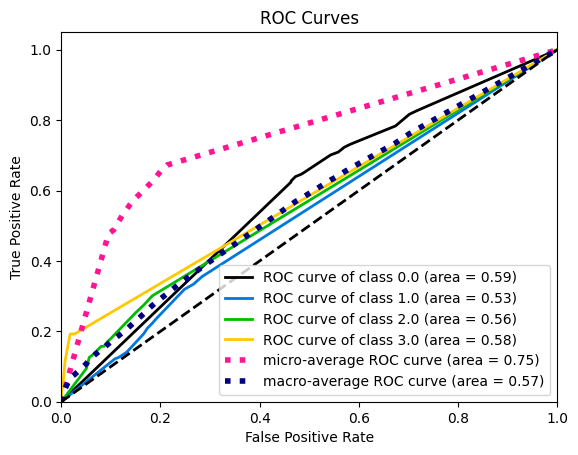

In [18]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

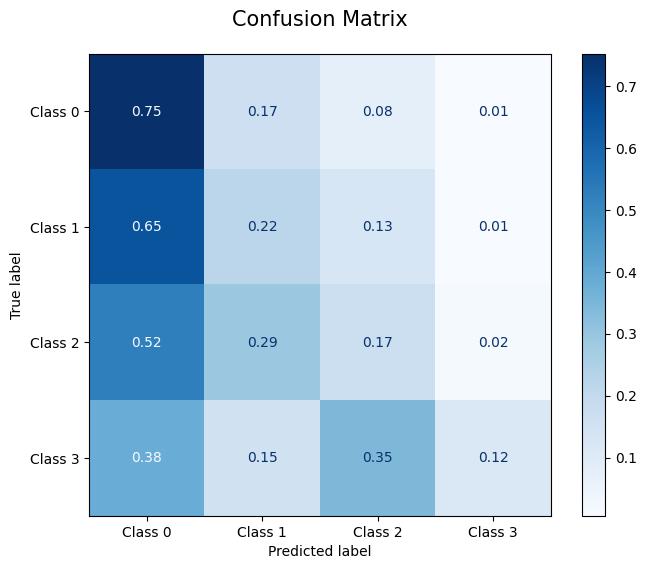

In [19]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Selection

## Variance Threshold

In [20]:
np.histogram(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])

(array([59,  1,  0,  0,  0,  0,  0,  0,  0,  1]),
 array([7.33745391e-02, 6.63265119e+02, 1.32645686e+03, 1.98964861e+03,
        2.65284035e+03, 3.31603210e+03, 3.97922384e+03, 4.64241559e+03,
        5.30560733e+03, 5.96879908e+03, 6.63199082e+03]))

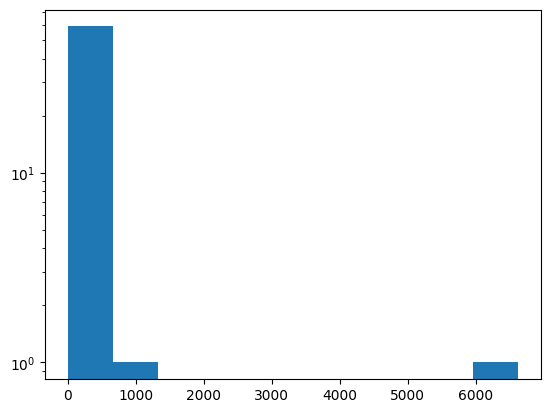

In [21]:
plt.hist(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])
plt.yscale('log')
plt.show()

In [22]:
from sklearn.feature_selection import VarianceThreshold

In [23]:
(.8 * (1 - .8))

0.15999999999999998

In [24]:
sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_train_sel = sel.fit_transform(X_train)

X_train_sel.shape

(5922, 57)

In [25]:
X_train.shape

(5922, 63)

In [26]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.5772261623325453
F1-score [0.74191719 0.22851153 0.16936937 0.04878049]
              precision    recall  f1-score   support

         0.0      0.736     0.747     0.742      1750
         1.0      0.228     0.229     0.229       476
         2.0      0.175     0.164     0.169       286
         3.0      0.067     0.038     0.049        26

    accuracy                          0.577      2538
   macro avg      0.301     0.295     0.297      2538
weighted avg      0.571     0.577     0.574      2538



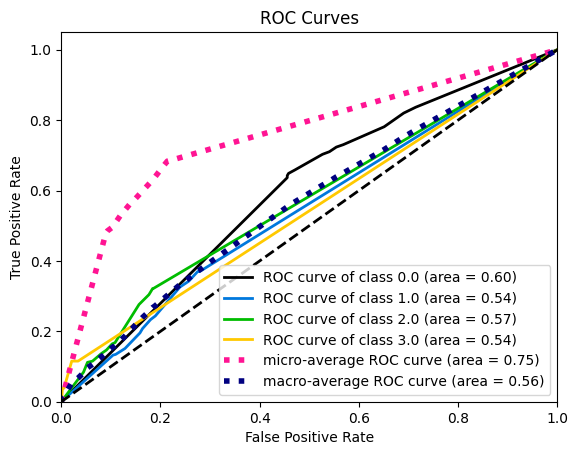

In [27]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

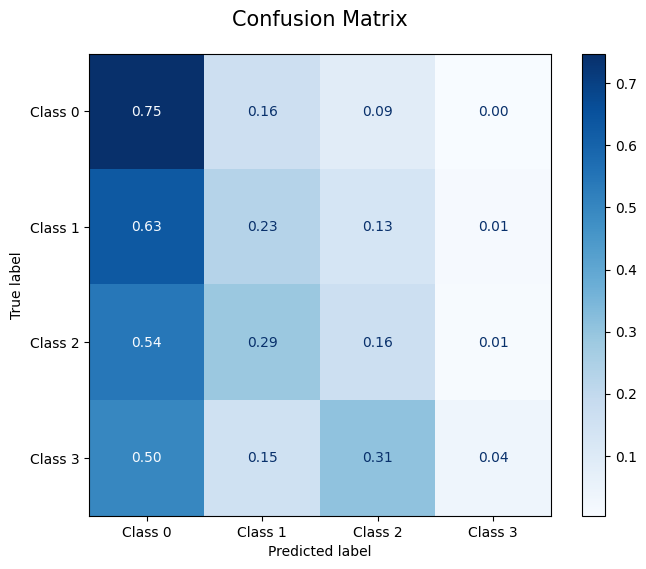

In [28]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Univariate Feature Selection

In [29]:
from sklearn.feature_selection import SelectKBest

In [30]:
sel = SelectKBest(k=40, score_func=f_classif)
X_train_sel = sel.fit_transform(X_train, y_train)

X_train_sel.shape

(5922, 40)

In [31]:
sel.scores_

array([  0.52868899,  99.55960365,  17.0857121 ,   0.73501278,
         1.09599406,   2.0293284 , 115.78263676,  75.56117056,
        29.71074077,   6.2943735 ,   1.40290708,  20.34713005,
         1.22636206,   0.95857315,   1.59775476,   1.09482956,
         0.43795149,  78.22119889,   4.23456647,  10.30458007,
         8.98809543,   6.79925975,   8.91024114,  40.01951704,
        15.85329309,   1.91743496,  13.96111786,   3.41266567,
         9.24982531,   9.89507058,   5.4163654 ,   3.07617414,
         1.30227308,  17.82077884,  26.28795791,  74.35968708,
        78.99390253,  63.80932648,  88.66425564,  31.0344326 ,
        30.31765244,  38.92381926,  14.00055436,  77.96356209,
        56.33946033,  83.62785806,  81.67649325,  73.58720125,
        27.55649665,   0.3510465 ,   4.42509881,   1.39594612,
         0.75303259,   2.0977389 ,  37.83841228,  43.71196864,
         0.39734873,  89.70239807,  17.5059004 ,   2.6119873 ,
        10.14560144,   0.3510465 ,   1.52037869])

In [32]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.5709219858156028
F1-score [0.73516889 0.21428571 0.17889088 0.0952381 ]
              precision    recall  f1-score   support

         0.0      0.730     0.740     0.735      1750
         1.0      0.214     0.214     0.214       476
         2.0      0.183     0.175     0.179       286
         3.0      0.125     0.077     0.095        26

    accuracy                          0.571      2538
   macro avg      0.313     0.302     0.306      2538
weighted avg      0.566     0.571     0.568      2538



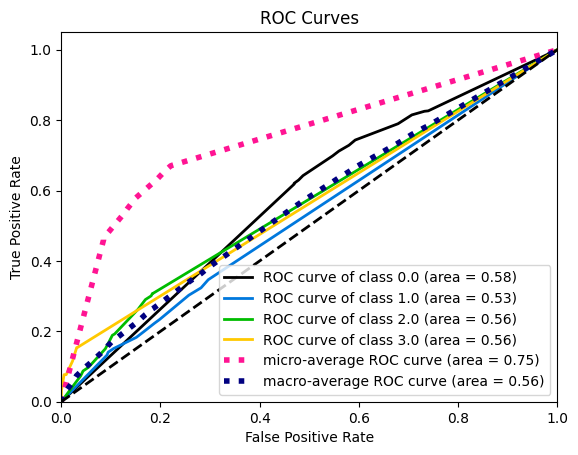

In [33]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

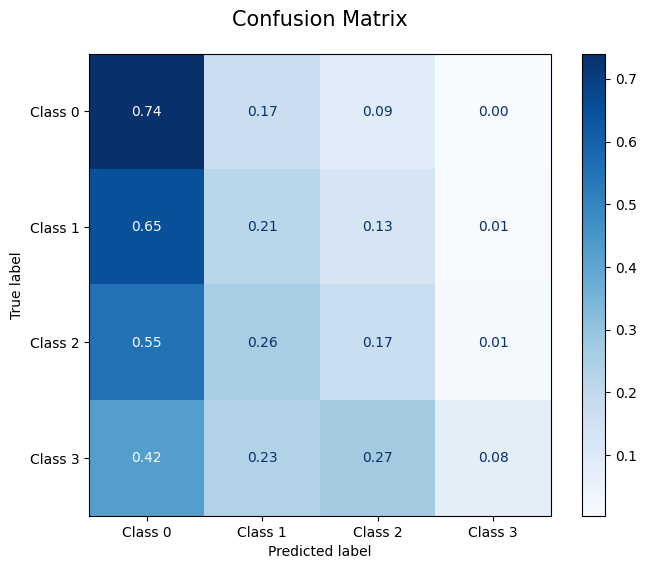

In [34]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Recursive Feature Elimination (RFE)

In [35]:
from sklearn.feature_selection import RFE

In [36]:
sel = RFE(DecisionTreeClassifier(), n_features_to_select=4)
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 4)

In [37]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.5898345153664303
F1-score [0.74765323 0.20937841 0.18036072 0.10526316]
              precision    recall  f1-score   support

         0.0      0.723     0.774     0.748      1750
         1.0      0.218     0.202     0.209       476
         2.0      0.211     0.157     0.180       286
         3.0      0.167     0.077     0.105        26

    accuracy                          0.590      2538
   macro avg      0.330     0.302     0.311      2538
weighted avg      0.565     0.590     0.576      2538



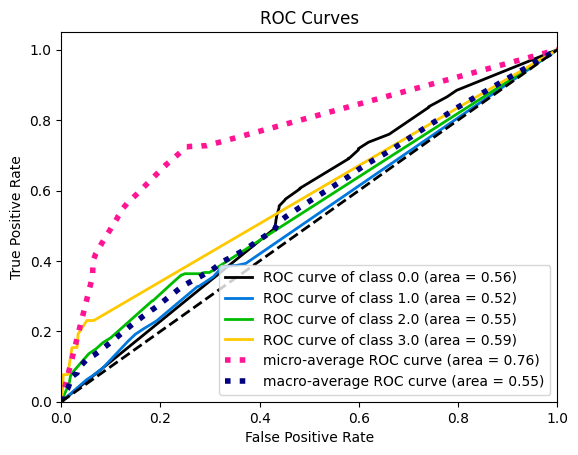

In [38]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

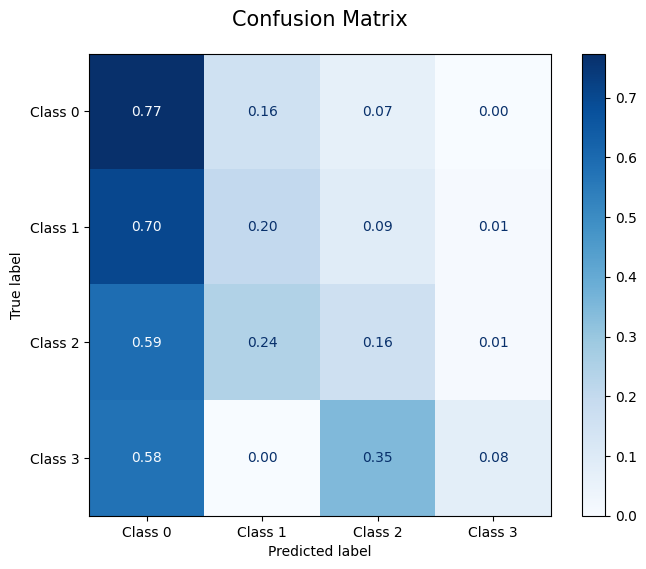

In [39]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Select Form Model
Meta-transformer for selecting features based on importance weights.

In [40]:
from sklearn.feature_selection import SelectFromModel

In [41]:
sel = SelectFromModel(DecisionTreeClassifier())
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 27)

In [42]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.5752561071710008
F1-score [0.7360913  0.24922118 0.16931217 0.09756098]
              precision    recall  f1-score   support

         0.0      0.735     0.737     0.736      1750
         1.0      0.246     0.252     0.249       476
         2.0      0.171     0.168     0.169       286
         3.0      0.133     0.077     0.098        26

    accuracy                          0.575      2538
   macro avg      0.321     0.308     0.313      2538
weighted avg      0.574     0.575     0.574      2538



In [43]:
# 1. Get the boolean mask (True for kept features, False for removed)
mask = sel.get_support()

# 2. Apply this mask to your ORIGINAL column names
# Replace 'df' with the name of your original DataFrame
original_feature_names = df.columns
real_feature_names = original_feature_names[mask]

# 3. Create the cleaned-up importance table
feature_importance_df = pd.DataFrame({
    'Feature': real_feature_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                                   Feature  Importance
2                          Physical-Height    0.080352
22                         SDS-SDS_Total_T    0.056208
1                          CGAS-CGAS_Score    0.050721
20                       PAQ_C-PAQ_C_Total    0.050350
21                       SDS-SDS_Total_Raw    0.048540
7                     Physical-Systolic_BP    0.045146
9                               FGC-FGC_CU    0.044586
5                    Physical-Diastolic_BP    0.042651
4             Physical-Waist_Circumference    0.040326
14                             BIA-BIA_DEE    0.039037
0                          Basic_Demos-Age    0.038338
12                             BIA-BIA_BMC    0.038334
6                       Physical-HeartRate    0.038116
17                             BIA-BIA_ICW    0.038008
8               Fitness_Endurance-Time_Sec    0.033637
13                             BIA-BIA_BMI    0.032567
24                        Physical-BMI_New    0.030091
26        

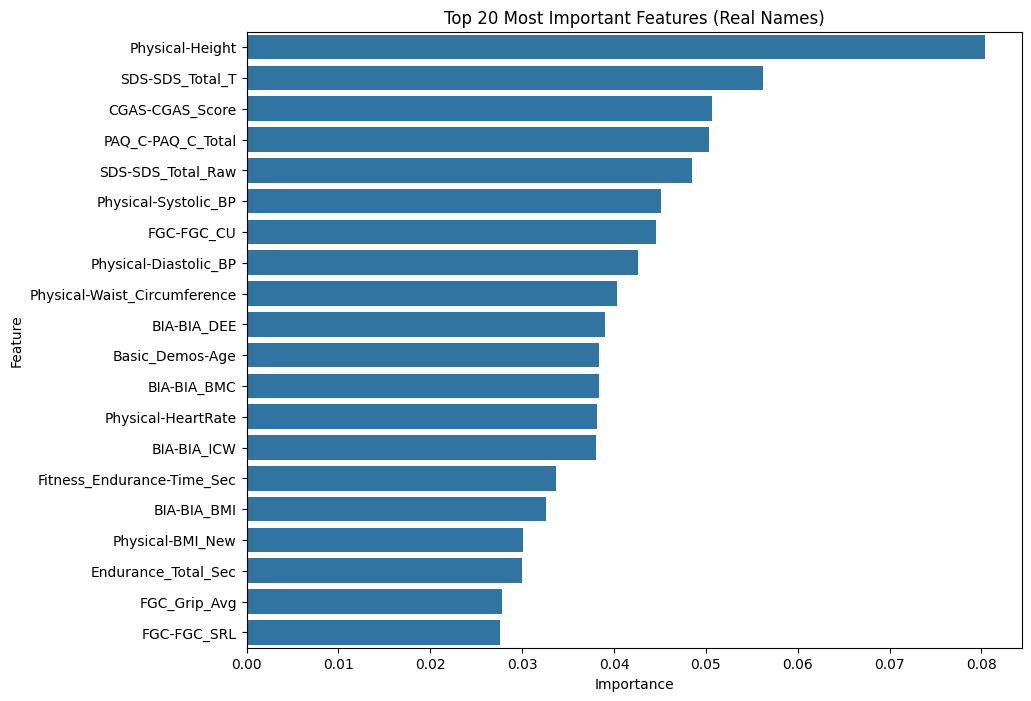

In [44]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Most Important Features (Real Names)')
plt.show()

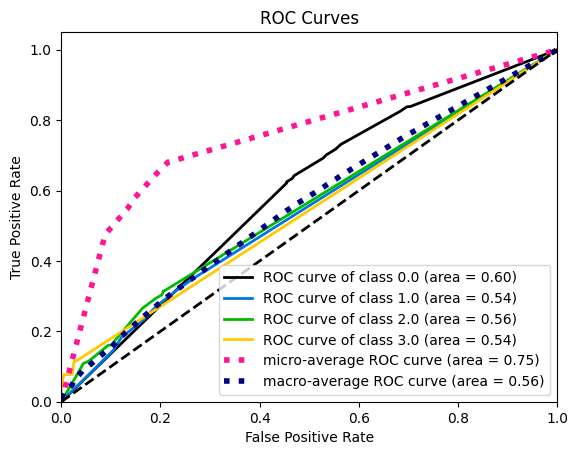

In [45]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

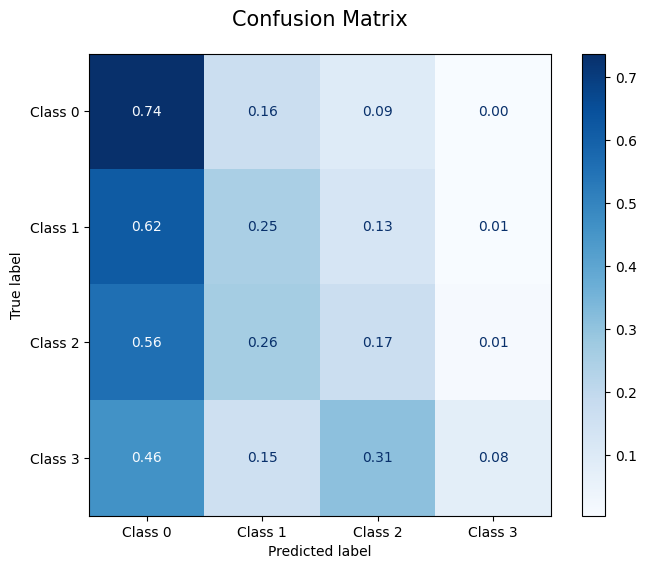

In [46]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### Gradient Boosting

In [47]:
import xgboost as xgb

In [48]:
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 33)

In [49]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.5815602836879432
F1-score [0.74220963 0.24974411 0.15589354 0.13953488]
              precision    recall  f1-score   support

         0.0      0.736     0.749     0.742      1750
         1.0      0.244     0.256     0.250       476
         2.0      0.171     0.143     0.156       286
         3.0      0.176     0.115     0.140        26

    accuracy                          0.582      2538
   macro avg      0.332     0.316     0.322      2538
weighted avg      0.574     0.582     0.578      2538



In [50]:
# Access the fitted XGBoost model from the selector
trained_xgb = sel.estimator_

# Get importance (Gain represents the improvement in accuracy brought by a feature)
importance = trained_xgb.get_booster().get_score(importance_type='gain')

# Sort and print for better readability
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
print(sorted_importance)

[('f6', 2.2715370655059814), ('f57', 2.040026903152466), ('f2', 1.728919267654419), ('f28', 1.5661100149154663), ('f4', 1.5079973936080933), ('f17', 1.4343843460083008), ('f44', 1.408573031425476), ('f55', 1.3853718042373657), ('f54', 1.35825777053833), ('f19', 1.346999168395996), ('f7', 1.3313740491867065), ('f47', 1.28974187374115), ('f43', 1.2882710695266724), ('f36', 1.2818752527236938), ('f42', 1.275834083557129), ('f35', 1.2719498872756958), ('f8', 1.2606505155563354), ('f62', 1.2590224742889404), ('f1', 1.2582714557647705), ('f20', 1.2545689344406128), ('f46', 1.2442229986190796), ('f40', 1.242621660232544), ('f34', 1.2303135395050049), ('f38', 1.2277681827545166), ('f15', 1.2041550874710083), ('f21', 1.2031304836273193), ('f39', 1.1942479610443115), ('f23', 1.1921249628067017), ('f22', 1.1828014850616455), ('f29', 1.1773631572723389), ('f33', 1.1761211156845093), ('f11', 1.1700438261032104), ('f45', 1.1659774780273438), ('f58', 1.1603370904922485), ('f60', 1.1235928535461426), 

In [51]:
original_cols = df.columns 

# Apply the mask to get only the features the selector kept
selected_names = original_cols[sel.get_support()]

# Create the table
dt_importance = pd.DataFrame({
    'Feature': selected_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- XGboost feature Importance ---")
print(dt_importance.head(20))

--- XGboost feature Importance ---
                         Feature  Importance
3                Physical-Height    0.086766
6           Physical-Systolic_BP    0.052947
30               SDS-SDS_Total_T    0.051330
8                     FGC-FGC_CU    0.046963
19                   BIA-BIA_DEE    0.045998
2                CGAS-CGAS_Score    0.044743
21                  BIA-BIA_FFMI    0.042317
29             SDS-SDS_Total_Raw    0.042094
9                   FGC-FGC_GSND    0.040943
5   Physical-Waist_Circumference    0.038341
4                Physical-Weight    0.038259
7     Fitness_Endurance-Time_Sec    0.037677
32           Endurance_Total_Sec    0.037480
25                   BIA-BIA_LDM    0.034819
16                   BIA-BIA_BMC    0.032800
24                   BIA-BIA_ICW    0.032512
0                Basic_Demos-Age    0.031961
13                    FGC-FGC_PU    0.030872
17                   BIA-BIA_BMI    0.029944
15                    FGC-FGC_TL    0.027403


In [52]:
importance_dict = trained_xgb.get_booster().get_score(importance_type='gain')

# 2. Map 'f#' to the column name at that index
# We use the original_cols list we defined above
real_names_dict = {}
for f_code, score in importance_dict.items():
    index = int(f_code.replace('f', ''))
    name = original_cols[index]
    real_names_dict[name] = score

# 3. Create the sorted table
xgb_importance = pd.DataFrame({
    'Feature': list(real_names_dict.keys()),
    'Gain': list(real_names_dict.values())
}).sort_values(by='Gain', ascending=False)

print("\n--- XGBoost Importance (Gain) ---")
print(xgb_importance.head(10))


--- XGBoost Importance (Gain) ---
                                   Feature      Gain
6                          Physical-Height  2.271537
57  PreInt_EduHx-computerinternet_hoursday  2.040027
2                          Basic_Demos-Sex  1.728919
28                        FGC-FGC_SRR_Zone  1.566110
4                          CGAS-CGAS_Score  1.507997
17                              FGC-FGC_CU  1.434384
44                             BIA-BIA_LDM  1.408573
55                         SDS-SDS_Total_T  1.385372
54                       SDS-SDS_Total_Raw  1.358258
19                            FGC-FGC_GSND  1.346999


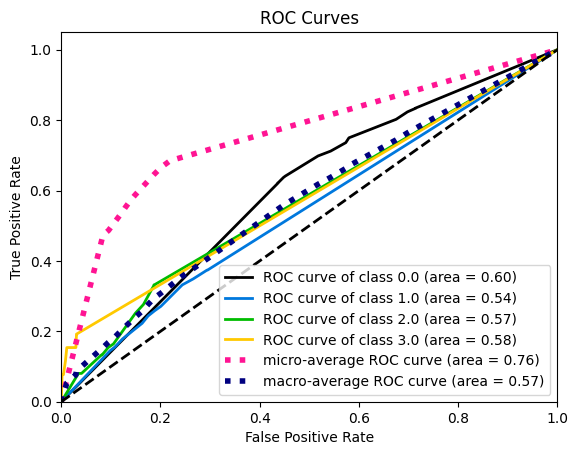

In [53]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

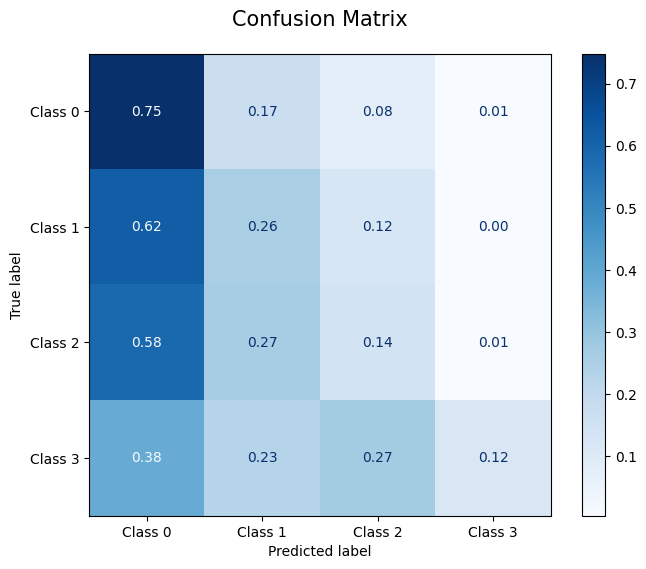

In [54]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Projection

## Principal Component Analysis

In [55]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler   

In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [58]:
X_train_pca.shape

(5922, 2)

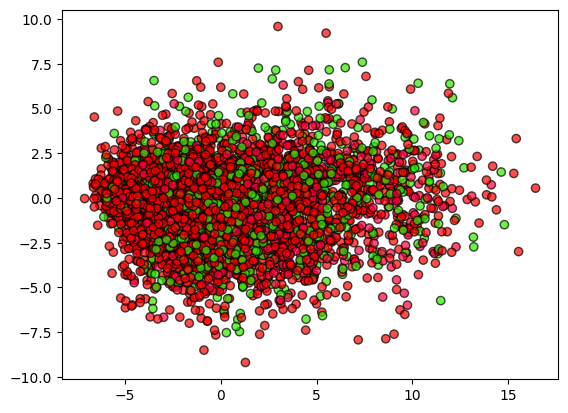

In [59]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
            cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [60]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5760441292356187
F1-score [0.7354874  0.18322296 0.14373717 0.06451613]
              precision    recall  f1-score   support

         0.0       0.71      0.77      0.74      1750
         1.0       0.19      0.17      0.18       476
         2.0       0.17      0.12      0.14       286
         3.0       0.20      0.04      0.06        26

    accuracy                           0.58      2538
   macro avg       0.32      0.28      0.28      2538
weighted avg       0.54      0.58      0.56      2538



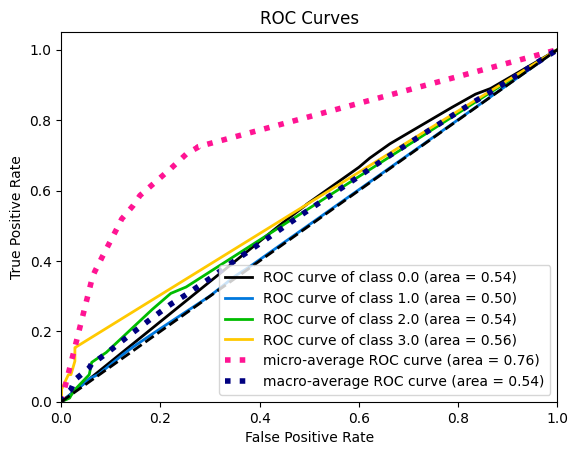

In [61]:
y_score = clf.predict_proba(X_test_pca)
plot_roc(y_test, y_score)
plt.show()

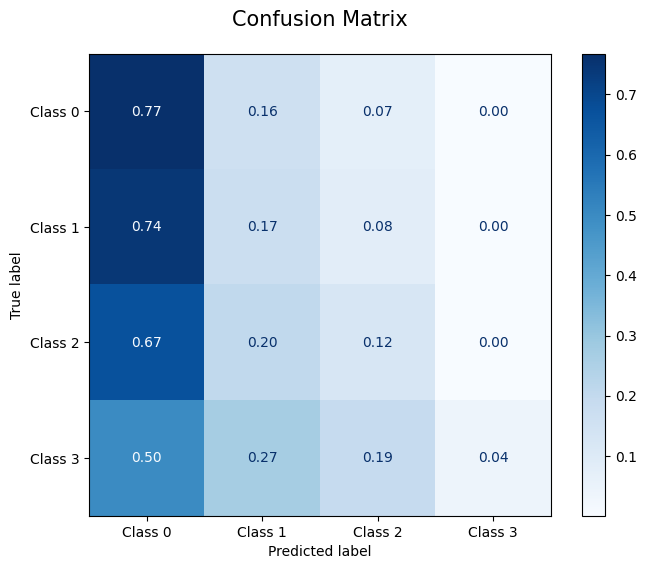

In [62]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

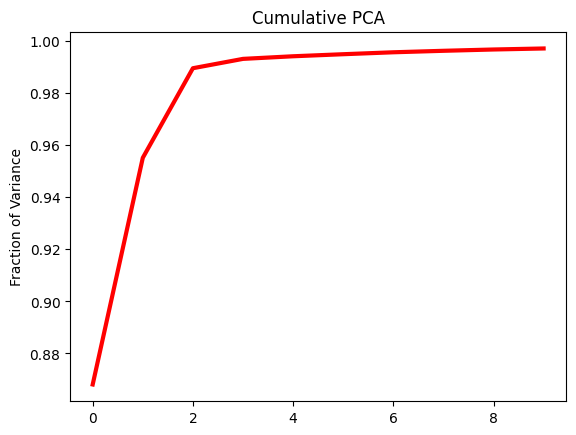

In [63]:
plt.plot(np.cumsum(PCA(n_components=10).fit(X).explained_variance_ratio_), lw=3, color='r', ms=2)
plt.title("Cumulative PCA")
plt.ylabel("Fraction of Variance")
plt.show()

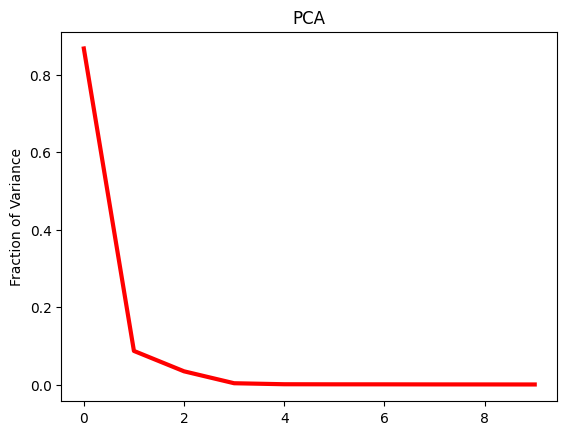

In [64]:
plt.plot(PCA(n_components=10).fit(X).explained_variance_ratio_, lw=3, color='r', ms=2)
plt.title("PCA")
plt.ylabel("Fraction of Variance")
plt.show()

# Random Subspace Projection

In [65]:
from sklearn import random_projection

In [66]:
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=None)
X_train_rsp = rsp.fit_transform(X_train_scaled)
X_test_rsp = rsp.transform(X_test_scaled)
X_train_rsp.shape

(5922, 2)

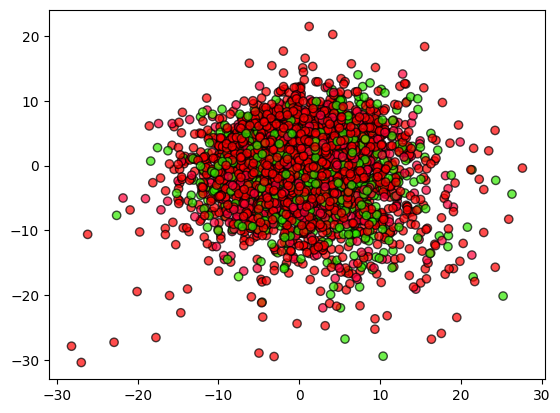

In [67]:
plt.scatter(X_train_rsp[:, 0], X_train_rsp[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [68]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_rsp, y_train)

y_pred = clf.predict(X_test_rsp)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.570527974783294
F1-score [0.73316845 0.17540107 0.1358811  0.        ]
              precision    recall  f1-score   support

         0.0       0.71      0.76      0.73      1750
         1.0       0.18      0.17      0.18       476
         2.0       0.17      0.11      0.14       286
         3.0       0.00      0.00      0.00        26

    accuracy                           0.57      2538
   macro avg       0.26      0.26      0.26      2538
weighted avg       0.54      0.57      0.55      2538



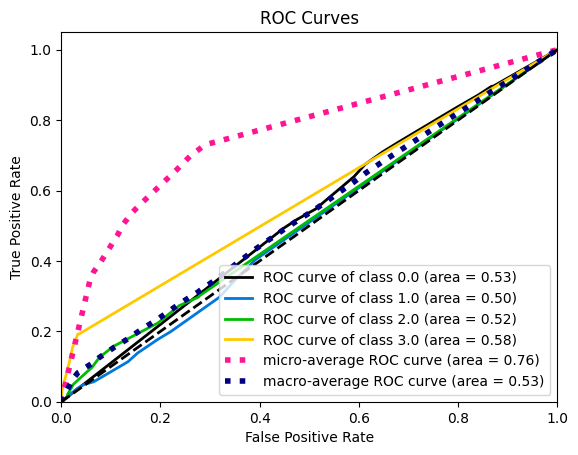

In [69]:
y_score = clf.predict_proba(X_test_rsp)
plot_roc(y_test, y_score)
plt.show()

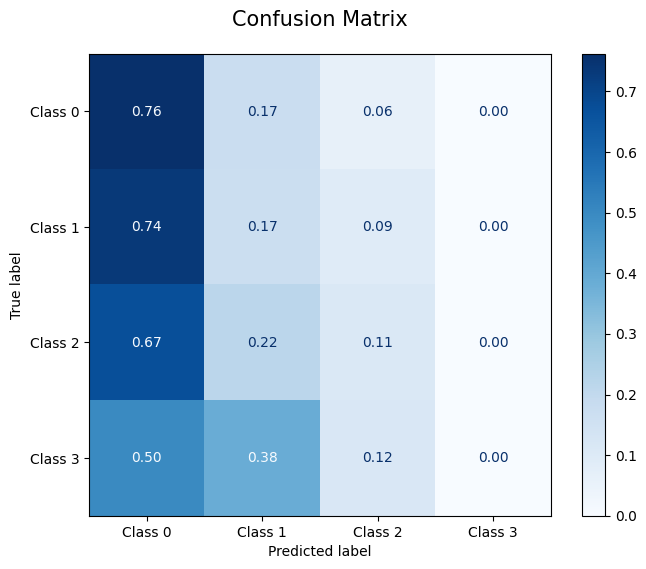

In [70]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Multi Dimensional Scaling

In [75]:
from sklearn.manifold import MDS

In [76]:
# Specifichiamo n_init e init per evitare i FutureWarning
mds = MDS(
    n_components=2, 
    n_init=4,           # Valore attuale di default (cambierà a 1 in futuro)
    init='random',      # Valore attuale di default (cambierà a 'classical_mds')
    normalized_stress='auto',
    random_state=42     # Sempre consigliato per rendere i risultati riproducibili
)

X_train_mds = mds.fit_transform(X_train_scaled)
print(X_train_mds.shape)

(5922, 2)


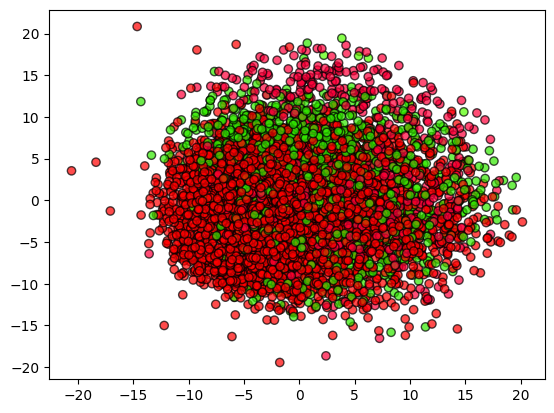

In [77]:
plt.scatter(X_train_mds[:, 0], X_train_mds[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [78]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_mds, y_train)

y_pred = clf.predict(X_train_mds)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.8537656197230665
F1-score [0.91415752 0.73267327 0.67296137 0.35955056]
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91      4083
         1.0       0.77      0.70      0.73      1111
         2.0       0.79      0.59      0.67       666
         3.0       0.59      0.26      0.36        62

    accuracy                           0.85      5922
   macro avg       0.76      0.62      0.67      5922
weighted avg       0.85      0.85      0.85      5922



## IsoMap

In [71]:
from sklearn.manifold import Isomap

In [72]:
iso = Isomap(n_components=2, n_neighbors=8) # n_neighbors=5 is the default, but it is important to specify it here to avoid a warning about future changes in the default value
X_train_iso = iso.fit_transform(X_train_scaled)
X_test_iso = iso.transform(X_test_scaled)
X_train_iso.shape

(5922, 2)

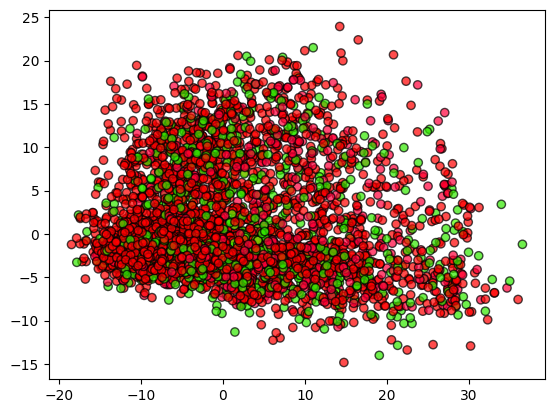

In [73]:
plt.scatter(X_train_iso[:, 0], X_train_iso[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [74]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_iso, y_train)

y_pred = clf.predict(X_test_iso)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5788022064617809
F1-score [0.74029524 0.17123288 0.14931238 0.12121212]
              precision    recall  f1-score   support

         0.0       0.71      0.77      0.74      1750
         1.0       0.19      0.16      0.17       476
         2.0       0.17      0.13      0.15       286
         3.0       0.29      0.08      0.12        26

    accuracy                           0.58      2538
   macro avg       0.34      0.29      0.30      2538
weighted avg       0.55      0.58      0.56      2538



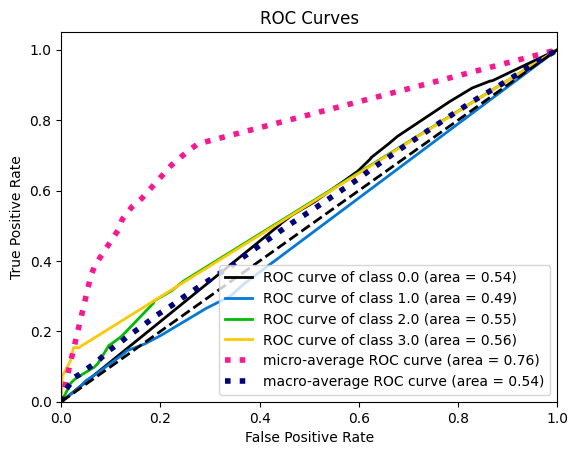

In [75]:
y_score = clf.predict_proba(X_test_iso)
plot_roc(y_test, y_score)
plt.show()

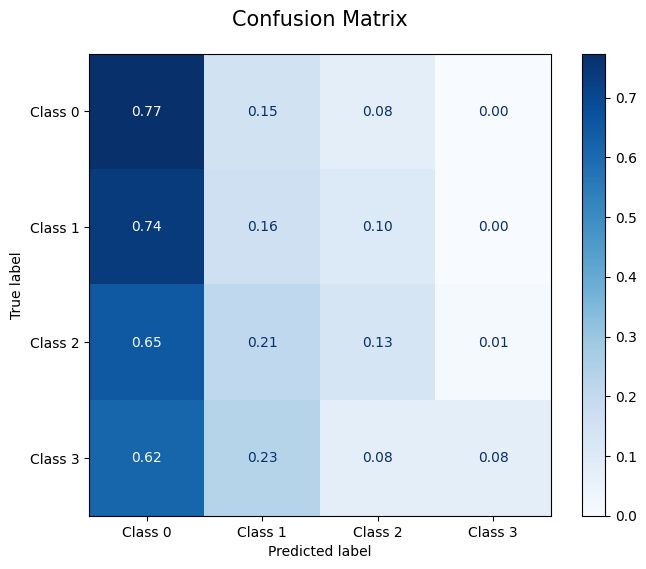

In [76]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## t-SNE

In [77]:
from sklearn.manifold import TSNE

In [ ]:
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train_scaled)
X_train_tsne.shape

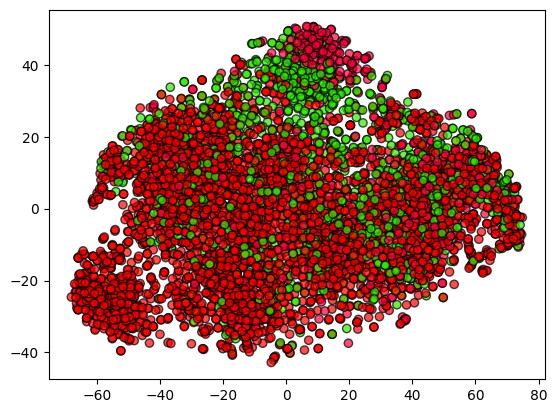

In [87]:
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [88]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_tsne, y_train)

y_pred = clf.predict(X_train_tsne)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.8677811550151976
F1-score [0.92349857 0.76309689 0.70529801 0.34482759]
              precision    recall  f1-score   support

         0.0       0.90      0.95      0.92      4083
         1.0       0.79      0.74      0.76      1111
         2.0       0.79      0.64      0.71       666
         3.0       0.60      0.24      0.34        62

    accuracy                           0.87      5922
   macro avg       0.77      0.64      0.68      5922
weighted avg       0.86      0.87      0.86      5922

